# Analysing data from `desinfo_vacinal` project

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Train data

In [8]:
df_train = pd.read_csv("data.csv")
df_train.head()

,source,text,label
0,athus,a resposta da anvisa ao pedido de liberação da...,True
1,athus,doria pede senso de urgência da anvisa para ap...,True
2,athus,já dizia sun tzu a melhor parte de ser um teór...,True
3,athus,desconheço a autoria mas esse texto abalou min...,True
4,athus,redução de impostostarifas governo jair messia...,False


In [9]:
df_train["label"].value_counts()

label
False    3871
True     1404
Name: count, dtype: int64

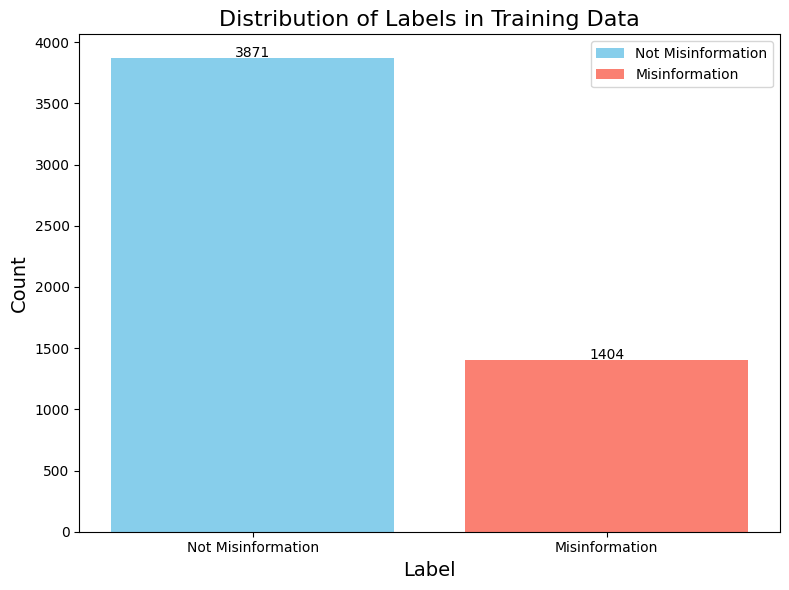

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

label_counts = df_train["label"].value_counts()

x = label_counts.index
y = label_counts.values

ax.bar(x[0], y[0], color='skyblue', label='Not Misinformation')
ax.bar(x[1], y[1], color='salmon', label='Misinformation')

for i, v in enumerate(y):
    ax.text(i, v + 5, str(v), ha='center', fontsize=10)

ax.set_title("Distribution of Labels in Training Data", fontsize=16)
ax.set_xlabel("Label", fontsize=14)
ax.set_ylabel("Count", fontsize=14)

ax.legend()

plt.xticks(label_counts.index, ['Not Misinformation', 'Misinformation'])
plt.tight_layout()
plt.show()

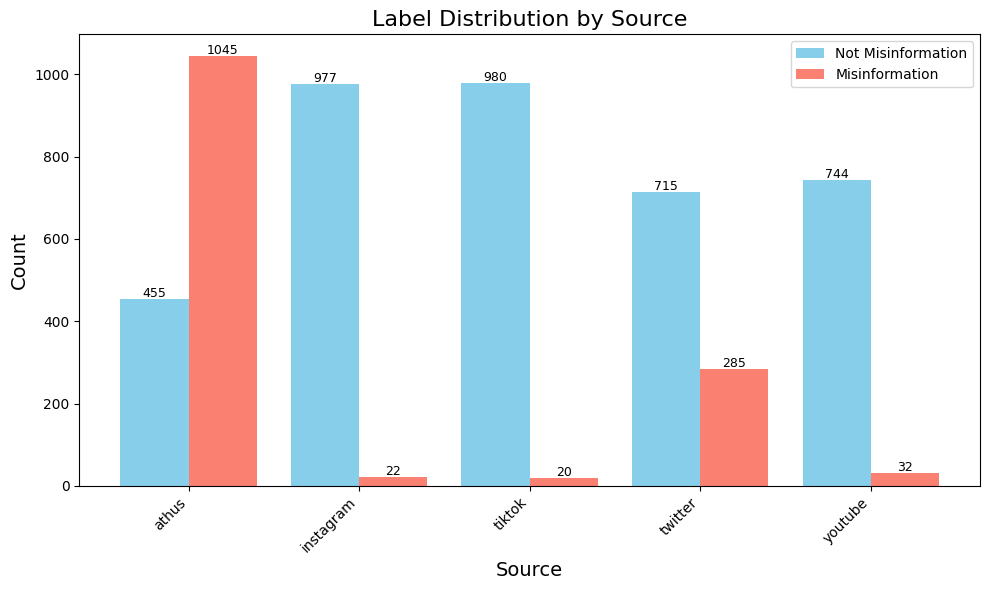

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

counts = (
    df_train.groupby(["source", "label"])
    .size()
    .unstack(fill_value=0)
)

if isinstance(counts.columns, pd.MultiIndex):
    counts.columns = counts.columns.get_level_values(-1)

if counts.columns.duplicated().any():
    counts = counts.groupby(level=0, axis=1).sum()

try:
    counts.columns = counts.columns.astype(int)
except Exception:
    pass

# Ensure both columns [0, 1] exist in a stable order
counts = counts.reindex(columns=[0, 1], fill_value=0)

sources = counts.index.astype(str)
x = np.arange(len(sources))
width = 0.4

ax.bar(x - width/2, counts[0].to_numpy(), width, label="Not Misinformation", color="skyblue")
ax.bar(x + width/2, counts[1].to_numpy(), width, label="Misinformation", color="salmon")

for i in range(len(sources)):
    ax.text(i - width/2, counts[0].to_numpy()[i] + 5, str(counts[0].to_numpy()[i]), ha='center', fontsize=9)
    ax.text(i + width/2, counts[1].to_numpy()[i] + 5, str(counts[1].to_numpy()[i]), ha='center', fontsize=9)

ax.set_title("Label Distribution by Source", fontsize=16)
ax.set_xlabel("Source", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(sources, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()